In [216]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [217]:
df = pd.read_csv("mushrooms.csv")
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [218]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

### checking for missing values or duplicates

In [219]:
print(f"nulls per column:\n{df.isnull().sum()}")
print(f"number of duplicates: {df.duplicated().sum()}")

nulls per column:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64
number of duplicates: 0


### splitting the data

In [220]:
X = df.drop(columns=["class"])
y = df["class"]
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
trainning_data = pd.concat([Xtrain, ytrain], axis=1)

### calculating the priors

In [221]:
class_counts = ytrain.value_counts()
print(f"total samples: {len(ytrain)}")
print(class_counts)
priors = class_counts / len(ytrain)
priors = priors.to_dict()
print(f"priors:\n{priors}")

total samples: 6499
class
e    3365
p    3134
Name: count, dtype: int64
priors:
{'e': 0.5177719649176796, 'p': 0.48222803508232037}


### calculating the likelihoods

In [222]:
likelihoods = {"e": {}, "p": {}}
class_e = trainning_data[trainning_data["class"] == "e"]
class_p = trainning_data[trainning_data["class"] == "p"]
features = np.array(Xtrain.columns)
for column in features:
    likelihoods["e"][column] = (class_e[column].value_counts() / len(class_e)).to_dict()
    likelihoods["p"][column] = (class_p[column].value_counts() / len(class_p)).to_dict()
print(f"likelihoods:\n{likelihoods}")

likelihoods:
{'e': {'cap-shape': {'x': 0.4710252600297177, 'f': 0.3708766716196137, 'b': 0.09301634472511144, 'k': 0.05705794947994056, 's': 0.008023774145616641}, 'cap-surface': {'f': 0.3696879643387816, 'y': 0.3589895988112927, 's': 0.2713224368499257}, 'cap-color': {'n': 0.2962852897473997, 'g': 0.2436849925705795, 'w': 0.17473997028231797, 'e': 0.14829123328380386, 'y': 0.09361069836552749, 'p': 0.014561664190193165, 'b': 0.013075780089153046, 'c': 0.008023774145616641, 'u': 0.004160475482912333, 'r': 0.003566121842496285}, 'bruises': {'t': 0.6552748885586924, 'f': 0.3447251114413076}, 'odor': {'n': 0.8136701337295691, 'a': 0.0950965824665676, 'l': 0.0912332838038633}, 'gill-attachment': {'f': 0.9548291233283804, 'a': 0.04517087667161961}, 'gill-spacing': {'c': 0.7161961367013373, 'w': 0.2838038632986627}, 'gill-size': {'b': 0.9364041604754829, 'n': 0.06359583952451708}, 'gill-color': {'w': 0.23298662704309064, 'n': 0.22585438335809807, 'p': 0.1976225854383358, 'u': 0.1054977711738

### generating predictions

In [223]:
classes = np.array(y.unique())
class_e_prob = []
class_p_prob = []
for index, row in Xtest.iterrows():
    pred_e = priors["e"]
    pred_p = priors["p"]
    for col, feature in zip(row, features):
        pred_e *= likelihoods["e"][feature].get(col, 1e-9)
        pred_p *= likelihoods["p"][feature].get(col, 1e-9)
    class_e_prob.append(pred_e)
    class_p_prob.append(pred_p)

### making the classifier decsision

In [224]:
predictions = []
for prob_e, prob_p in zip(class_e_prob, class_p_prob):
    if(prob_e > prob_p):
        predictions.append("e")
    else: 
        predictions.append("p")
print(predictions)

['e', 'p', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'e', 'e', 'e', 'e', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'p', 'e', 'p', 'e', 'p', 'e', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'p', 'e', 'e', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'p', 'e', 'p', 'e', 'p', 'p', 'p', 'e', 'p', 'p', 'p', 'e', 'p', 'p', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'p', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'e', 'p', 'p', 'e', 'p', 'e', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'p', 'e', 'e', 'e', 'e', 'e', 'e', 'p', 'p', 'p', 'p', 'p', 'p', 'p', 'e', 'e', 'p', 'p', 'p', 'e', 'e', 'e', 'p', 'p', 'e', 'p', 'p', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'e', 'p', 'e', 'p', 'e', 'p', 'p', 'p', 'p', 'e', 'e', 'e', 'e', 'p', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'e', 'e', 'p', 'e', 'e', 'p', 'p', 'e', 'e', 'p', 'e', 'e', 'e', 'e', 'p', 'e', 'e', 'e',

### evaluating the model

Accuracy Score: 0.9963076923076923


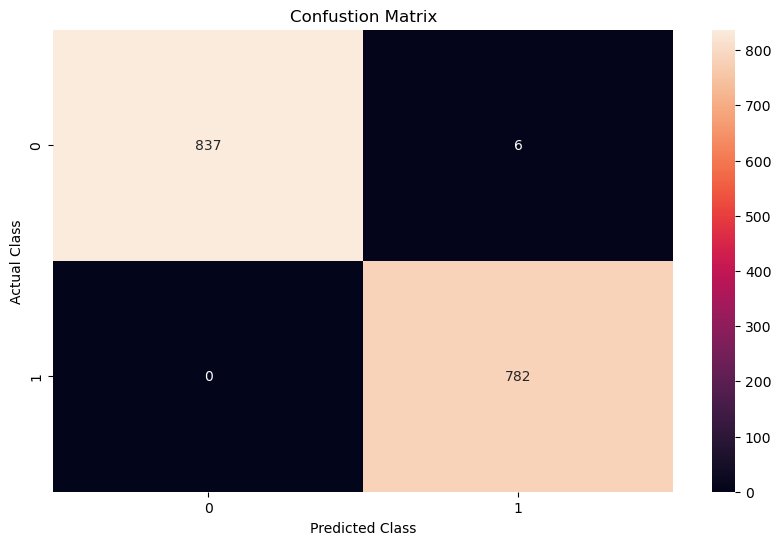

In [ ]:
accuracy = accuracy_score(ytest, predictions)
confusionMatrix = confusion_matrix(ytest, predictions)
print(f"Accuracy Score: {accuracy}")
plt.figure(figsize=(10, 6))
sns.heatmap(confusionMatrix, annot= True, fmt= "d")
plt.title("Confustion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [231]:
classificationReport = classification_report(ytest, predictions)
print(classificationReport)

              precision    recall  f1-score   support

           e       1.00      0.99      1.00       843
           p       0.99      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

